# **Step 2 :**

**1.Load your dataset**

In [ ]:
import pandas as pd

url = 'https://github.com/ArwaQumayri/loan-data-analysis/raw/refs/heads/main/loan_data.csv'

df = pd.read_csv(url)

**2.Perform basic data exploration**

- Display the first 5 rows

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


- Check the shape and data types

In [ ]:
print(df.shape)
df.dtypes

(45000, 14)


,0
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,int64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64


- Identify missing values and duplicate rows.

In [ ]:
print("missing value?\n" , df.isnull().sum())
print("\n dublicate? " , df.duplicated().sum())

missing value?
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

 dublicate?  0


**3.Generate descriptive statistics**

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


**4.Create visualizations**

- **Histogram**

In [ ]:
import numpy as np
df["person_income"]=np.log1p(df["person_income"])

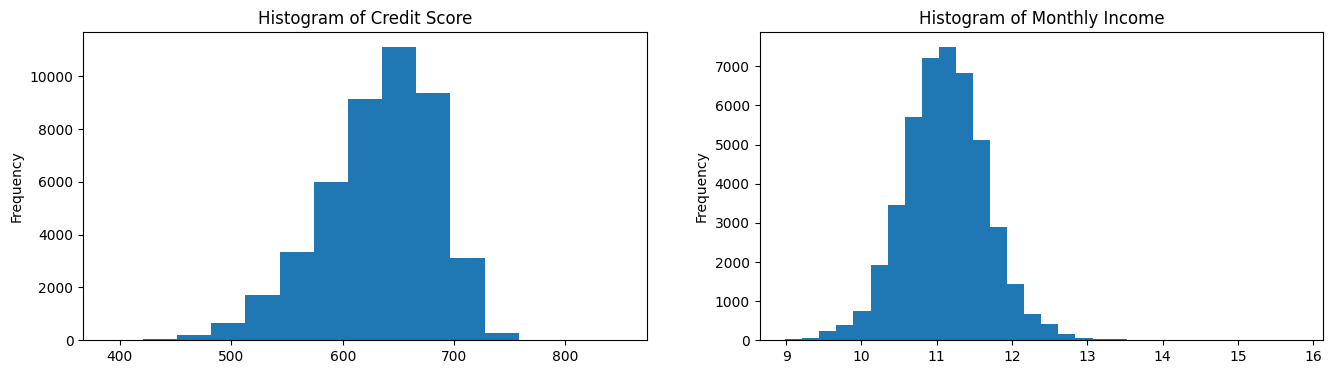

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(16,4))
df["credit_score"].plot(kind="hist", bins=15, ax=ax[0], title="Histogram of Credit Score")
df["person_income"].plot(kind="hist", bins = 30 ,ax=ax[1], title="Histogram of Monthly Income")
plt.show()

The first histogram shows that most customers have credit scores concentrated between 600 and 700, peaking around 650, with very few having scores below 500 or above 750, indicating a roughly normal distribution centered around the average score.

The second histogram, which represents log-transformed monthly income, reveals that the majority of customers have log(income) values between 10 and 12 (roughly equivalent to actual incomes between 22,000 and 160,000), with a symmetric, bell-shaped distribution and minimal presence of outliers.

- **Bar Plot**

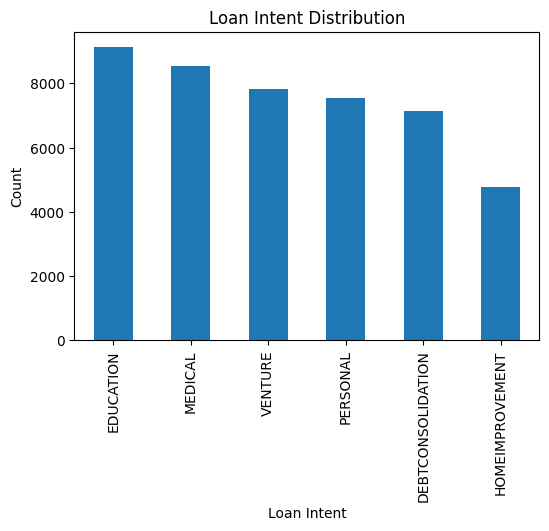

In [ ]:
df["loan_intent"].value_counts().plot(kind="bar", title="Loan Intent Distribution", figsize=(6,4))
plt.xlabel("Loan Intent")
plt.ylabel("Count")
plt.show()

The most common loan intent among applicants is Education, followed by Medical and Venture, indicating a high demand for loans in these categories.

Home Improvement has the lowest loan intent count, suggesting it is the least frequent reason customers apply for a loan in this dataset.

- **Pie Chart**

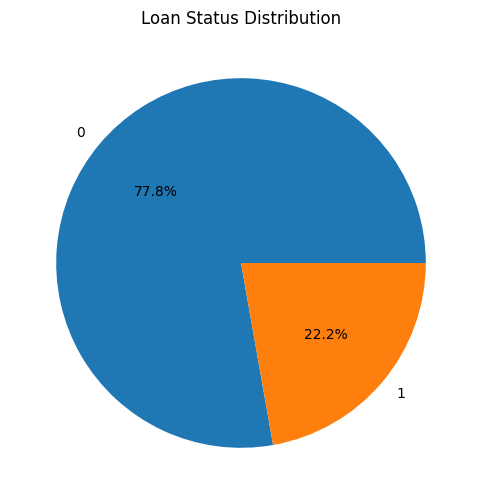

In [ ]:
df["loan_status"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6), title="Loan Status Distribution")
plt.ylabel("")
plt.show()

Most loans were rejected (77.8%, status = 0), while only 22.2% were approved (status = 1), showing class imbalance

- **Scatter Plot**

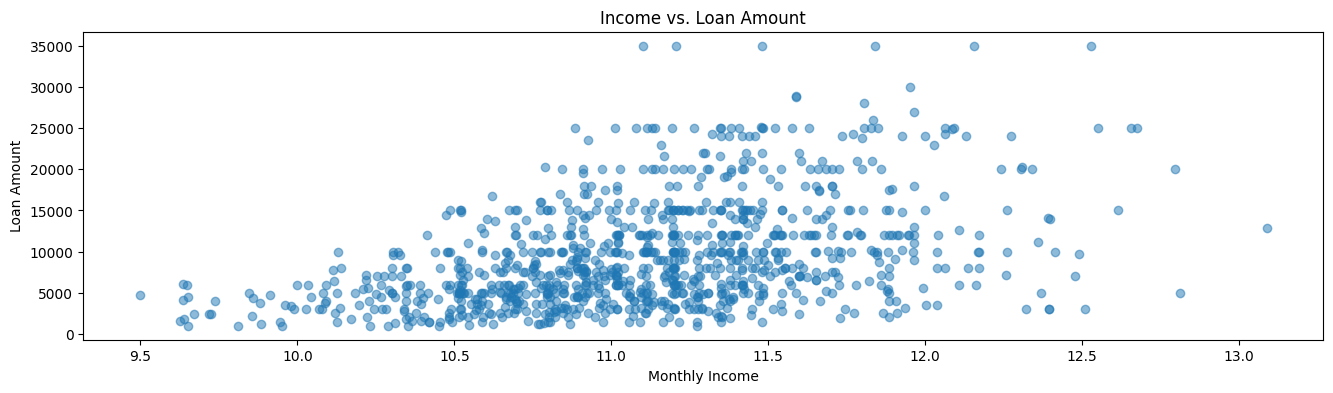

In [ ]:
sample_df = df.sample(n=1000 , random_state=42)
plt.figure(figsize=(16,4))
plt.scatter (sample_df["person_income"], sample_df["loan_amnt"], alpha=0.5)
plt.xlabel("Monthly Income")
plt.ylabel("Loan Amount")
plt.title("Income vs. Loan Amount")
plt.show()

The scatter plot shows that individuals with mid-range monthly incomes are not only the most frequent loan applicants but also tend to request higher loan amounts compared to those with very low or very high incomes.

# **Step 3 :**

**1. No Missing value and dublicate**

**2. Encode categorical variables and Normalize numerical data**


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
num_features = ["person_age", "person_income", "person_emp_exp", "loan_amnt",
                "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length", "credit_score"]
cat_features = ["person_gender", "person_education", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"]
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),  #Scale
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features) #Encode
])

**3.Split the dataset into train and test**

In [ ]:
from sklearn.model_selection import train_test_split
X = df[[
    "person_age", "person_income", "person_emp_exp", "loan_amnt", "loan_int_rate",
    "loan_percent_income", "cb_person_cred_hist_length", "credit_score",
    "person_gender", "person_education", "person_home_ownership", "loan_intent",
    "previous_loan_defaults_on_file"
]]
y = df["loan_status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (31500, 13)
Testing set size: (13500, 13)


 # **Step4 :**

**1.Train the model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
rf_model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42))
])

rf_model.fit(X_train_prepared, y_train)

Pipeline(steps=[('scale', StandardScaler()),
                ('clf',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

**2.Predict on the test set**

In [ ]:
y_pred = rf_model.predict(X_test_prepared)

**3.Result**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9256296296296296

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     10500
           1       0.89      0.76      0.82      3000

    accuracy                           0.93     13500
   macro avg       0.91      0.87      0.89     13500
weighted avg       0.92      0.93      0.92     13500


Confusion Matrix:
 [[10218   282]
 [  722  2278]]


# **Step 5 :**

**1. Accuracy, Precision, Recall, F1-score, and Confusion Matrix**







In [ ]:
#shown in step 4 , here listed separately
from sklearn.metrics import precision_score, recall_score, f1_score
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nConfusion Matrix:\n", cm)


Accuracy: 0.9256
Precision: 0.8898
Recall: 0.7593
F1-score: 0.8194

Confusion Matrix:
 [[10218   282]
 [  722  2278]]


- Visualization

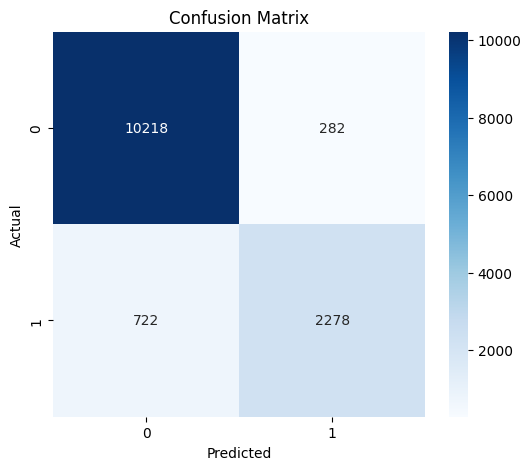

In [ ]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The model predicts class 0 well but misses some class 1 cases

**2.ROC curve**

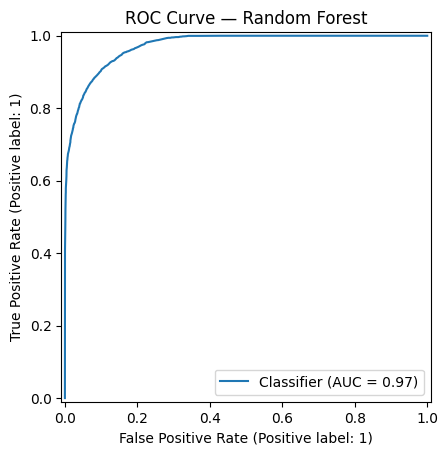

AUC: 0.9729210952380953


In [ ]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
y_proba = rf_model.predict_proba(X_test_prepared)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Random Forest")
plt.show()

print("AUC:", roc_auc_score(y_test, y_proba))


The model shows excellent class separation with strong overall performance